# Airline Passenger Satisfaction - Advanced Machine Learning Pipeline
# Author: Pedro M.
# Enhanced modeling with multiple algorithms, hyperparameter optimization, and interpretability

# 🤖 Airline Passenger Satisfaction - Advanced ML Modeling
# 
## 📋 Table of Contents
# 1. Setup & Configuration
# 2. DATA LOADING AND INITIAL EXPLORATION
# 3. DETAILED DATA ANALYSIS
# 4. ENHANCED FEATURE ENGINEERING
# 5. DATA PREPROCESSING FOR CATBOOST
# 6. CROSS-VALIDATION SETUP AND BASELINE MODEL
# 7. FEATURE IMPORTANCE ANALYSIS
# 8. HYPERPARAMETER OPTIMIZATION
# 9. 9. FINAL MODEL TRAINING
# 10. MODEL EVALUATION AND ANALYSIS
# 11. SAVE MODELS AND GENERATE PREDICTIONS
# 12. FINAL SUMMARY AND INSIGHTS
# 13. MODEL LOADING AND PREDICTION FUNCTIONS


## 1. Setup & Configuration

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
import os
import pickle
import json
from datetime import datetime
import time
from typing import Dict, List, Tuple, Any
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, 
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    make_scorer
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Advanced ML libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler

# Model interpretation
import shap

# 2. DATA LOADING AND INITIAL EXPLORATION

In [4]:


def load_and_explore_data():
    """Load data and perform initial exploration"""
    
    print("📊 Loading data...")
    train_df = pd.read_csv('data/train.csv')
    test_df = pd.read_csv('data/test.csv')
    
    print(f"✅ Data loaded successfully!")
    print(f"Training set shape: {train_df.shape}")
    print(f"Test set shape: {test_df.shape}")
    
    return train_df, test_df

def explore_dataset(df, dataset_name="Dataset"):
    """Comprehensive data exploration"""
    
    print(f"\n🔍 EXPLORING {dataset_name.upper()}")
    print("=" * 50)
    
    # Basic info
    print(f"📊 Shape: {df.shape}")
    print(f"📊 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n❌ Missing values:")
        missing_df = pd.DataFrame({
            'Column': missing.index,
            'Missing': missing.values,
            'Percentage': (missing / len(df) * 100).values
        })
        print(missing_df[missing_df['Missing'] > 0].to_string(index=False))
    else:
        print("\n✅ No missing values!")
    
    # Data types
    print(f"\n📋 Data types:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   {dtype}: {count} columns")
    
    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"\n🔄 Duplicate rows: {duplicates}")
    
    # Target analysis (if exists)
    if 'satisfaction' in df.columns:
        print(f"\n🎯 Target distribution:")
        target_dist = df['satisfaction'].value_counts()
        target_pct = df['satisfaction'].value_counts(normalize=True)
        
        for value, count in target_dist.items():
            pct = target_pct[value] * 100
            print(f"   {value}: {count:,} ({pct:.1f}%)")
        
        # Check class imbalance
        imbalance_ratio = target_dist.max() / target_dist.min()
        print(f"   Imbalance ratio: {imbalance_ratio:.2f}")
        if imbalance_ratio > 2:
            print("   ⚠️  Dataset is imbalanced - consider stratified sampling")
    
    return df

# Load and explore data
train_df, test_df = load_and_explore_data()
train_df = explore_dataset(train_df, "Training")
test_df = explore_dataset(test_df, "Test")



📊 Loading data...
✅ Data loaded successfully!
Training set shape: (103904, 25)
Test set shape: (25976, 25)

🔍 EXPLORING TRAINING
📊 Shape: (103904, 25)
📊 Memory usage: 49.8 MB

❌ Missing values:
                  Column  Missing  Percentage
Arrival Delay in Minutes      310    0.298352

📋 Data types:
   int64: 19 columns
   object: 5 columns
   float64: 1 columns

🔄 Duplicate rows: 0

🎯 Target distribution:
   neutral or dissatisfied: 58,879 (56.7%)
   satisfied: 45,025 (43.3%)
   Imbalance ratio: 1.31

🔍 EXPLORING TEST
📊 Shape: (25976, 25)
📊 Memory usage: 12.4 MB

❌ Missing values:
                  Column  Missing  Percentage
Arrival Delay in Minutes       83    0.319526

📋 Data types:
   int64: 19 columns
   object: 5 columns
   float64: 1 columns

🔄 Duplicate rows: 0

🎯 Target distribution:
   neutral or dissatisfied: 14,573 (56.1%)
   satisfied: 11,403 (43.9%)
   Imbalance ratio: 1.28


# 3. DETAILED DATA ANALYSIS

In [5]:
def analyze_numeric_features(df):
    """Analyze numeric features"""
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'satisfaction' in numeric_cols:
        numeric_cols.remove('satisfaction')
    
    print(f"\n📊 Numeric features analysis ({len(numeric_cols)} features):")
    
    # Basic statistics
    stats = df[numeric_cols].describe()
    print("\nBasic statistics:")
    print(stats.round(2))
    
    # Correlation with target (if available)
    if 'satisfaction' in df.columns:
        target_numeric = (df['satisfaction'] == 'satisfied').astype(int)
        correlations = df[numeric_cols].corrwith(target_numeric).abs().sort_values(ascending=False)
        
        print("\n🎯 Top correlations with satisfaction:")
        for feature, corr in correlations.head(10).items():
            print(f"   {feature}: {corr:.3f}")
    
    return numeric_cols

def analyze_categorical_features(df):
    """Analyze categorical features"""
    
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if 'satisfaction' in categorical_cols:
        categorical_cols.remove('satisfaction')
    
    print(f"\n📊 Categorical features analysis ({len(categorical_cols)} features):")
    
    for col in categorical_cols:
        unique_values = df[col].nunique()
        print(f"\n{col}:")
        print(f"   Unique values: {unique_values}")
        
        if unique_values <= 10:  # Show value counts for features with few categories
            value_counts = df[col].value_counts()
            for value, count in value_counts.items():
                pct = count / len(df) * 100
                print(f"     {value}: {count:,} ({pct:.1f}%)")
        else:
            print(f"   Top 5 values: {df[col].value_counts().head().to_dict()}")
    
    return categorical_cols

# Analyze features
numeric_features = analyze_numeric_features(train_df)
categorical_features = analyze_categorical_features(train_df)


📊 Numeric features analysis (20 features):

Basic statistics:
       Unnamed: 0         id        Age  Flight Distance  \
count   103904.00  103904.00  103904.00        103904.00   
mean     51951.50   64924.21      39.38          1189.45   
std      29994.65   37463.81      15.11           997.15   
min          0.00       1.00       7.00            31.00   
25%      25975.75   32533.75      27.00           414.00   
50%      51951.50   64856.50      40.00           843.00   
75%      77927.25   97368.25      51.00          1743.00   
max     103903.00  129880.00      85.00          4983.00   

       Inflight wifi service  Departure/Arrival time convenient  \
count              103904.00                          103904.00   
mean                    2.73                               3.06   
std                     1.33                               1.53   
min                     0.00                               0.00   
25%                     2.00                               2.

# 4. ENHANCED FEATURE ENGINEERING

In [6]:
def create_advanced_features(df):
    """
    Create engineered features with improved logic
    """
    df_new = df.copy()
    
    print("🔧 Creating advanced features...")
    
    # Define service columns
    service_cols = [
        'Inflight wifi service', 'Departure/Arrival time convenient',
        'Ease of Online booking', 'Gate location', 'Food and drink',
        'Online boarding', 'Seat comfort', 'Inflight entertainment',
        'On-board service', 'Leg room service', 'Baggage handling',
        'Checkin service', 'Inflight service', 'Cleanliness'
    ]
    
    # Service aggregate features
    print("   📊 Service aggregation features...")
    df_new['avg_service_rating'] = df[service_cols].mean(axis=1)
    df_new['min_service_rating'] = df[service_cols].min(axis=1)
    df_new['max_service_rating'] = df[service_cols].max(axis=1)
    df_new['service_rating_std'] = df[service_cols].std(axis=1)
    df_new['service_rating_range'] = df_new['max_service_rating'] - df_new['min_service_rating']
    
    # Count-based service features
    df_new['excellent_service_count'] = (df[service_cols] == 5).sum(axis=1)
    df_new['good_service_count'] = (df[service_cols] == 4).sum(axis=1)
    df_new['poor_service_count'] = (df[service_cols] <= 2).sum(axis=1)
    df_new['service_satisfaction_ratio'] = (df_new['excellent_service_count'] + df_new['good_service_count']) / len(service_cols)
    
    # Domain-specific service scores
    print("   🏢 Domain-specific service scores...")
    
    # Digital experience
    digital_cols = ['Inflight wifi service', 'Ease of Online booking', 'Online boarding']
    df_new['digital_experience_score'] = df[digital_cols].mean(axis=1)
    df_new['digital_experience_poor'] = (df_new['digital_experience_score'] <= 2).astype(int)
    
    # Physical comfort
    comfort_cols = ['Seat comfort', 'Leg room service', 'Cleanliness']
    df_new['comfort_score'] = df[comfort_cols].mean(axis=1)
    df_new['comfort_excellent'] = (df_new['comfort_score'] >= 4).astype(int)
    
    # Service quality
    service_quality_cols = ['Food and drink', 'Inflight entertainment', 'On-board service', 'Inflight service']
    df_new['service_quality_score'] = df[service_quality_cols].mean(axis=1)
    
    # Ground services
    ground_cols = ['Departure/Arrival time convenient', 'Gate location', 'Baggage handling', 'Checkin service']
    df_new['ground_service_score'] = df[ground_cols].mean(axis=1)
    
    # Delay features
    print("   ✈️ Advanced delay features...")
    df_new['departure_delay'] = df['Departure Delay in Minutes'].fillna(0)
    df_new['arrival_delay'] = df['Arrival Delay in Minutes'].fillna(0)
    df_new['total_delay'] = df_new['departure_delay'] + df_new['arrival_delay']
    df_new['delay_difference'] = df_new['arrival_delay'] - df_new['departure_delay']
    
    # Delay categories
    df_new['no_delay'] = (df_new['total_delay'] == 0).astype(int)
    df_new['minor_delay'] = ((df_new['total_delay'] > 0) & (df_new['total_delay'] <= 15)).astype(int)
    df_new['moderate_delay'] = ((df_new['total_delay'] > 15) & (df_new['total_delay'] <= 60)).astype(int)
    df_new['severe_delay'] = (df_new['total_delay'] > 60).astype(int)
    
    # Delay improvement (arrival delay less than departure delay)
    df_new['delay_improved'] = (df_new['delay_difference'] < -5).astype(int)
    df_new['delay_worsened'] = (df_new['delay_difference'] > 15).astype(int)
    
    # Customer and trip features
    print("   👤 Customer and trip features...")
    
    # Age groups
    df_new['age_group'] = pd.cut(df['Age'], 
                                bins=[0, 25, 35, 50, 65, 100], 
                                labels=['Young', 'Young_Adult', 'Middle_Age', 'Senior', 'Elderly'])
    
    # Age-related features
    df_new['is_young'] = (df['Age'] <= 25).astype(int)
    df_new['is_senior'] = (df['Age'] >= 60).astype(int)
    df_new['is_business_age'] = ((df['Age'] >= 30) & (df['Age'] <= 55)).astype(int)
    
    # Flight distance categories
    df_new['flight_distance_log'] = np.log1p(df['Flight Distance'])
    df_new['is_short_flight'] = (df['Flight Distance'] < 500).astype(int)
    df_new['is_medium_flight'] = ((df['Flight Distance'] >= 500) & (df['Flight Distance'] < 1500)).astype(int)
    df_new['is_long_flight'] = (df['Flight Distance'] >= 1500).astype(int)
    
    # Customer value features
    print("   💼 Customer value features...")
    df_new['is_business_loyal'] = ((df['Customer Type'] == 'Loyal Customer') & 
                                   (df['Class'] == 'Business')).astype(int)
    df_new['is_economy_loyal'] = ((df['Customer Type'] == 'Loyal Customer') & 
                                  (df['Class'] == 'Eco')).astype(int)
    df_new['is_first_time_business'] = ((df['Customer Type'] == 'disloyal Customer') & 
                                        (df['Class'] == 'Business')).astype(int)
    
    # Interaction features
    print("   🔗 Interaction features...")
    df_new['service_delay_interaction'] = df_new['avg_service_rating'] * (1 - df_new['total_delay'] / 100)
    df_new['class_service_match'] = 0
    
    # Business class should have high service scores
    business_mask = (df['Class'] == 'Business')
    df_new.loc[business_mask, 'class_service_match'] = (df_new.loc[business_mask, 'avg_service_rating'] >= 4).astype(int)
    
    # Economy class with surprisingly good service
    eco_mask = (df['Class'] == 'Eco')
    df_new.loc[eco_mask, 'class_service_match'] = (df_new.loc[eco_mask, 'avg_service_rating'] >= 3.5).astype(int)
    
    print(f"✅ Created {len(df_new.columns) - len(df.columns)} new features")
    print(f"   Total features now: {len(df_new.columns)}")
    
    return df_new

# Apply enhanced feature engineering
print("\n🔧 Applying enhanced feature engineering...")
train_df_enhanced = create_advanced_features(train_df)
test_df_enhanced = create_advanced_features(test_df)

# List new features
new_features = [col for col in train_df_enhanced.columns if col not in train_df.columns]
print(f"\n📊 New features created: {len(new_features)}")
for i, feature in enumerate(new_features, 1):
    print(f"   {i:2d}. {feature}")


🔧 Applying enhanced feature engineering...
🔧 Creating advanced features...
   📊 Service aggregation features...
   🏢 Domain-specific service scores...
   ✈️ Advanced delay features...
   👤 Customer and trip features...
   💼 Customer value features...
   🔗 Interaction features...
✅ Created 38 new features
   Total features now: 63
🔧 Creating advanced features...
   📊 Service aggregation features...
   🏢 Domain-specific service scores...
   ✈️ Advanced delay features...
   👤 Customer and trip features...
   💼 Customer value features...
   🔗 Interaction features...
✅ Created 38 new features
   Total features now: 63

📊 New features created: 38
    1. avg_service_rating
    2. min_service_rating
    3. max_service_rating
    4. service_rating_std
    5. service_rating_range
    6. excellent_service_count
    7. good_service_count
    8. poor_service_count
    9. service_satisfaction_ratio
   10. digital_experience_score
   11. digital_experience_poor
   12. comfort_score
   13. comfort_ex

# 5. DATA PREPROCESSING FOR CATBOOST

In [7]:
def prepare_data_for_catboost(train_df, test_df, target_col='satisfaction'):
    """
    Prepare data specifically for CatBoost
    """
    print("🎯 Preparing data for CatBoost...")
    
    # Define columns to exclude
    exclude_cols = ['Unnamed: 0', 'id', target_col]
    exclude_cols = [col for col in exclude_cols if col in train_df.columns]
    
    # Get feature columns
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    # Separate features and target
    X_train = train_df[feature_cols].copy()
    y_train = (train_df[target_col] == 'satisfied').astype(int)
    X_test = test_df[feature_cols].copy()
    
    print(f"✅ Feature columns: {len(feature_cols)}")
    print(f"✅ Training shape: {X_train.shape}")
    print(f"✅ Test shape: {X_test.shape}")
    
    # Identify column types
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"📊 Numeric features: {len(numeric_cols)}")
    print(f"📊 Categorical features: {len(categorical_cols)}")
    
    # Handle missing values in numeric columns (minimal preprocessing for CatBoost)
    # CatBoost handles NaN well, but let's check for excessive missing values
    missing_threshold = 0.7
    
    for col in numeric_cols:
        missing_pct = X_train[col].isnull().sum() / len(X_train)
        if missing_pct > missing_threshold:
            print(f"⚠️  High missing values in {col}: {missing_pct:.1%}")
            # Simple median imputation for extremely missing values
            imputer = SimpleImputer(strategy='median')
            X_train[col] = imputer.fit_transform(X_train[[col]]).ravel()
            X_test[col] = imputer.transform(X_test[[col]]).ravel()
    
    # Ensure categorical columns are object type
    for col in categorical_cols:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)
    
    # Get categorical feature indices for CatBoost
    cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_cols]
    
    # Create preprocessing info
    preprocessing_info = {
        'feature_columns': feature_cols,
        'numeric_columns': numeric_cols,
        'categorical_columns': categorical_cols,
        'categorical_indices': cat_features_indices,
        'target_encoding': {'satisfied': 1, 'neutral or dissatisfied': 0}
    }
    
    print(f"✅ Categorical feature indices: {cat_features_indices}")
    print(f"✅ Target distribution: {y_train.value_counts().to_dict()}")
    
    return X_train, X_test, y_train, preprocessing_info

# Prepare data
X_train, X_test, y_train, preprocessing_info = prepare_data_for_catboost(
    train_df_enhanced, test_df_enhanced
)

# Save preprocessing info
joblib.dump(preprocessing_info, 'models/preprocessing_info.pkl')
print("💾 Preprocessing info saved!")

🎯 Preparing data for CatBoost...
✅ Feature columns: 60
✅ Training shape: (103904, 60)
✅ Test shape: (25976, 60)
📊 Numeric features: 55
📊 Categorical features: 5
✅ Categorical feature indices: [0, 1, 3, 4, 47]
✅ Target distribution: {0: 58879, 1: 45025}
💾 Preprocessing info saved!


# 6. CROSS-VALIDATION SETUP AND BASELINE MODEL

In [8]:
def setup_cross_validation(X, y, n_splits=5):
    """Setup stratified cross-validation"""
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    print(f"🔄 Cross-validation setup: {n_splits} folds")
    print(f"   Stratified: ✅ (maintains class distribution)")
    
    # Check fold distributions
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        train_dist = y.iloc[train_idx].mean()
        val_dist = y.iloc[val_idx].mean()
        print(f"   Fold {fold+1}: Train={train_dist:.3f}, Val={val_dist:.3f}")
    
    return skf

def train_baseline_catboost(X_train, y_train, cv_folds, cat_features):
    """Train baseline CatBoost with cross-validation"""
    
    print("\n🚀 Training baseline CatBoost model...")
    
    # Baseline parameters
    baseline_params = {
        'iterations': 1000,
        'depth': 6,
        'learning_rate': 0.1,
        'cat_features': cat_features,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 100,
        'random_seed': 42,
        'verbose': False
    }
    
    cv_scores = []
    cv_models = []
    
    for fold, (train_idx, val_idx) in enumerate(cv_folds.split(X_train, y_train)):
        print(f"   📊 Training fold {fold + 1}...")
        
        # Split data
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model
        model = CatBoostClassifier(**baseline_params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=(X_fold_val, y_fold_val),
            plot=False,
            verbose=False
        )
        
        # Evaluate
        pred_proba = model.predict_proba(X_fold_val)[:, 1]
        auc_score = roc_auc_score(y_fold_val, pred_proba)
        cv_scores.append(auc_score)
        cv_models.append(model)
        
        print(f"      AUC: {auc_score:.4f}")
    
    mean_auc = np.mean(cv_scores)
    std_auc = np.std(cv_scores)
    
    print(f"\n🎯 Baseline CV Results:")
    print(f"   Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"   All folds: {[f'{score:.4f}' for score in cv_scores]}")
    
    return cv_models, cv_scores, baseline_params

# Setup cross-validation
cv = setup_cross_validation(X_train, y_train)

# Train baseline model
baseline_models, baseline_scores, baseline_params = train_baseline_catboost(
    X_train, y_train, cv, preprocessing_info['categorical_indices']
)


🔄 Cross-validation setup: 5 folds
   Stratified: ✅ (maintains class distribution)
   Fold 1: Train=0.433, Val=0.433
   Fold 2: Train=0.433, Val=0.433
   Fold 3: Train=0.433, Val=0.433
   Fold 4: Train=0.433, Val=0.433
   Fold 5: Train=0.433, Val=0.433

🚀 Training baseline CatBoost model...
   📊 Training fold 1...
      AUC: 0.9953
   📊 Training fold 2...
      AUC: 0.9947
   📊 Training fold 3...
      AUC: 0.9955
   📊 Training fold 4...
      AUC: 0.9954
   📊 Training fold 5...
      AUC: 0.9948

🎯 Baseline CV Results:
   Mean AUC: 0.9951 ± 0.0004
   All folds: ['0.9953', '0.9947', '0.9955', '0.9954', '0.9948']


# 7. FEATURE IMPORTANCE ANALYSIS


📊 Feature Importance Analysis (Top 25)...
🏆 Top 25 Most Important Features:
------------------------------------------------------------
 7. Inflight wifi service                 26.0 ±  1.0 (Stable)
 4. Type of Travel                        19.8 ±  1.6 (Stable)
 2. Customer Type                          5.9 ±  0.7 (Stable)
56. is_business_loyal                      5.7 ±  0.7 (Stable)
12. Online boarding                        5.4 ±  0.4 (Stable)
10. Gate location                          4.7 ±  0.5 (Stable)
18. Checkin service                        3.1 ±  0.5 (Stable)
17. Baggage handling                       2.7 ±  0.4 (Stable)
 3. Age                                    2.0 ±  0.1 (Stable)
31. service_satisfaction_ratio             1.9 ±  0.3 (Stable)
 5. Class                                  1.9 ±  0.3 (Stable)
19. Inflight service                       1.7 ±  0.1 (Stable)
28. excellent_service_count                1.7 ±  0.2 (Stable)
13. Seat comfort                           

C:\Users\P02\AppData\Local\Temp\ipykernel_15248\3164593738.py:16: RuntimeWarning: invalid value encountered in divide
  'importance_cv': std_importance / mean_importance  # Coefficient of variation


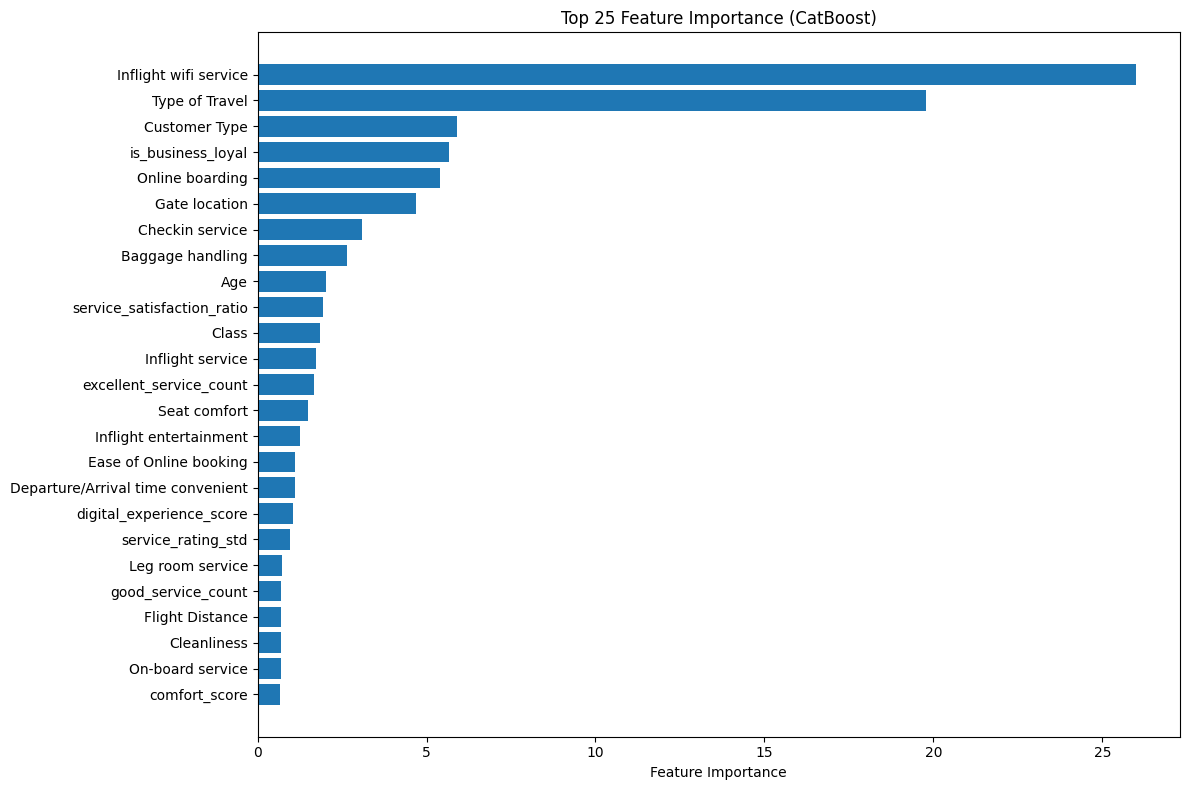

In [7]:
def analyze_feature_importance(models, feature_names, top_n=20):
    """Analyze feature importance across CV folds"""
    
    print(f"\n📊 Feature Importance Analysis (Top {top_n})...")
    
    # Calculate mean importance across folds
    importance_matrix = np.array([model.get_feature_importance() for model in models])
    mean_importance = importance_matrix.mean(axis=0)
    std_importance = importance_matrix.std(axis=0)
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': mean_importance,
        'importance_std': std_importance,
        'importance_cv': std_importance / mean_importance  # Coefficient of variation
    }).sort_values('importance_mean', ascending=False)
    
    print(f"🏆 Top {top_n} Most Important Features:")
    print("-" * 60)
    
    top_features = importance_df.head(top_n)
    for idx, row in top_features.iterrows():
        stability = "Stable" if row['importance_cv'] < 0.3 else "Variable"
        print(f"{row.name+1:2d}. {row['feature']:<35} {row['importance_mean']:6.1f} ± {row['importance_std']:4.1f} ({stability})")
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features_plot = importance_df.head(top_n)
    
    plt.barh(range(len(top_features_plot)), top_features_plot['importance_mean'])
    plt.yticks(range(len(top_features_plot)), top_features_plot['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importance (CatBoost)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return importance_df

# Analyze feature importance
feature_importance_df = analyze_feature_importance(
    baseline_models, X_train.columns, top_n=25
)

# 8. HYPERPARAMETER OPTIMIZATION

In [8]:
def optimize_catboost_hyperparameters(X_train, y_train, cv_folds, cat_features, n_trials=50):
    """Optimize CatBoost hyperparameters using Optuna"""
    
    try:
        import optuna
        from optuna.samplers import TPESampler
    except ImportError:
        print("⚠️  Optuna not installed. Skipping hyperparameter optimization.")
        print("   Install with: pip install optuna")
        return None
    
    print(f"\n🔍 Hyperparameter Optimization ({n_trials} trials)...")
    
    def objective(trial):
        # Define parameter space
        params = {
            'iterations': 1000,
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'cat_features': cat_features,
            'eval_metric': 'AUC',
            'early_stopping_rounds': 100,
            'random_seed': 42,
            'verbose': False
        }
        
        # Cross-validation
        cv_scores = []
        for train_idx, val_idx in cv_folds.split(X_train, y_train):
            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]
            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]
            
            model = CatBoostClassifier(**params)
            model.fit(
                X_fold_train, y_fold_train,
                eval_set=(X_fold_val, y_fold_val),
                plot=False,
                verbose=False
            )
            
            pred_proba = model.predict_proba(X_fold_val)[:, 1]
            auc_score = roc_auc_score(y_fold_val, pred_proba)
            cv_scores.append(auc_score)
        
        return np.mean(cv_scores)
    
    # Create study
    sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    
    # Optimize
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f"\n🏆 Optimization Results:")
    print(f"   Best AUC: {study.best_value:.4f}")
    print(f"   Best parameters:")
    for param, value in study.best_params.items():
        print(f"      {param}: {value}")
    
    # Create optimized parameters
    optimized_params = {
        'iterations': 1000,
        'cat_features': cat_features,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 100,
        'random_seed': 42,
        'verbose': False,
        **study.best_params
    }
    
    return optimized_params, study

# Hyperparameter optimization (comment out if you don't have optuna)
try:
    optimized_params, study = optimize_catboost_hyperparameters(
        X_train, y_train, cv, preprocessing_info['categorical_indices'], n_trials=30
    )
    print("✅ Hyperparameter optimization completed!")
except:
    print("⚠️  Using baseline parameters (optuna not available)")
    optimized_params = baseline_params

# %%

[I 2025-06-09 23:14:29,482] A new study created in memory with name: no-name-ce095cf4-1707-44c2-ae11-5fa21ebc32e9



🔍 Hyperparameter Optimization (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-09 23:15:52,341] Trial 0 finished with value: 0.9947865546928629 and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 0.038720902953704193, 'border_count': 166}. Best is trial 0 with value: 0.9947865546928629.
[I 2025-06-09 23:20:24,414] Trial 1 finished with value: 0.9942211409832662 and parameters: {'depth': 5, 'learning_rate': 0.01699897838270077, 'l2_leaf_reg': 3.3323645788192616e-08, 'border_count': 226}. Best is trial 0 with value: 0.9947865546928629.
[I 2025-06-09 23:21:49,873] Trial 2 finished with value: 0.9944069358719665 and parameters: {'depth': 8, 'learning_rate': 0.11114989443094977, 'l2_leaf_reg': 1.5320059381854043e-08, 'border_count': 249}. Best is trial 0 with value: 0.9947865546928629.


Training has stopped (degenerate solution on iteration 185, probably too small l2-regularization, try to increase it)


...

[I 2025-06-09 23:27:52,684] Trial 4 finished with value: 0.9949402871864088 and parameters: {'depth': 6, 'learning_rate': 0.05958389350068958, 'l2_leaf_reg': 7.71800699380605e-05, 'border_count': 97}. Best is trial 4 with value: 0.9949402871864088.


Training has stopped (degenerate solution on iteration 931, probably too small l2-regularization, try to increase it)
Training has stopped (degenerate solution on iteration 503, probably too small l2-regularization, try to increase it)


[I 2025-06-09 23:33:03,682] Trial 5 finished with value: 0.994849245817807 and parameters: {'depth': 8, 'learning_rate': 0.01607123851203988, 'l2_leaf_reg': 4.258943089524393e-06, 'border_count': 114}. Best is trial 4 with value: 0.9949402871864088.
[I 2025-06-09 23:34:20,336] Trial 6 finished with value: 0.9945643299685349 and parameters: {'depth': 7, 'learning_rate': 0.14447746112718687, 'l2_leaf_reg': 6.267062696005991e-07, 'border_count': 147}. Best is trial 4 with value: 0.9949402871864088.
[I 2025-06-09 23:40:19,705] Trial 7 finished with value: 0.9949598180952017 and parameters: {'depth': 8, 'learning_rate': 0.011711509955524094, 'l2_leaf_reg': 0.0029369981104377003, 'border_count': 70}. Best is trial 7 with value: 0.9949598180952017.
[I 2025-06-09 23:42:34,938] Trial 8 finished with value: 0.9947604927701594 and parameters: {'depth': 4, 'learning_rate': 0.2521267904777921, 'l2_leaf_reg': 4.905556676028774, 'border_count': 213}. Best is trial 7 with value: 0.9949598180952017.
[I

Training has stopped (degenerate solution on iteration 282, probably too small l2-regularization, try to increase it)


[I 2025-06-09 23:57:40,941] Trial 12 finished with value: 0.9947926900973101 and parameters: {'depth': 8, 'learning_rate': 0.05754376370923953, 'l2_leaf_reg': 5.4525300201499886e-05, 'border_count': 52}. Best is trial 11 with value: 0.9949601920343867.
[I 2025-06-10 00:04:28,150] Trial 13 finished with value: 0.995141877326952 and parameters: {'depth': 10, 'learning_rate': 0.03460102621817302, 'l2_leaf_reg': 0.16505863700695908, 'border_count': 85}. Best is trial 13 with value: 0.995141877326952.
[I 2025-06-10 00:11:49,916] Trial 14 finished with value: 0.9952189951256925 and parameters: {'depth': 10, 'learning_rate': 0.03306316465562099, 'l2_leaf_reg': 0.9478184390242493, 'border_count': 86}. Best is trial 14 with value: 0.9952189951256925.
[I 2025-06-10 00:21:54,519] Trial 15 finished with value: 0.9952841336457258 and parameters: {'depth': 10, 'learning_rate': 0.030218642282987398, 'l2_leaf_reg': 2.1085226947509614, 'border_count': 178}. Best is trial 15 with value: 0.99528413364572

# 9. FINAL MODEL TRAINING

In [11]:
def train_final_model(X_train, y_train, X_test, params, cv_folds):
    """Train final model with optimized parameters"""
    
    print("\n🎯 Training final optimized model...")
    
    # Train models on each fold
    final_models = []
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv_folds.split(X_train, y_train)):
        print(f"   📊 Training final model - Fold {fold + 1}...")
        
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model
        model = CatBoostClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=(X_fold_val, y_fold_val),
            plot=False,
            verbose=False
        )
        
        # Evaluate
        pred_proba = model.predict_proba(X_fold_val)[:, 1]
        auc_score = roc_auc_score(y_fold_val, pred_proba)
        cv_scores.append(auc_score)
        final_models.append(model)
        
        print(f"      Fold {fold + 1} AUC: {auc_score:.4f}")
    
    # Final CV performance
    mean_auc = np.mean(cv_scores)
    std_auc = np.std(cv_scores)
    
    print(f"\n🏆 Final Model CV Performance:")
    print(f"   Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
    
    # Train on full dataset for production model
    print("\n🚀 Training production model on full dataset...")
    production_model = CatBoostClassifier(**params)
    production_model.fit(X_train, y_train, verbose=False)
    
    # Generate predictions for test set
    print("🔮 Generating test predictions...")
    
    # Ensemble predictions (average of CV models)
    ensemble_preds = np.zeros(len(X_test))
    for model in final_models:
        ensemble_preds += model.predict_proba(X_test)[:, 1]
    ensemble_preds /= len(final_models)
    
    # Production model predictions
    production_preds = production_model.predict_proba(X_test)[:, 1]
    
    return final_models, production_model, ensemble_preds, production_preds, cv_scores

# Train final model
final_models, production_model, ensemble_predictions, production_predictions, final_cv_scores = train_final_model(
    X_train, y_train, X_test, optimized_params, cv
)


🎯 Training final optimized model...
   📊 Training final model - Fold 1...
      Fold 1 AUC: 0.9954
   📊 Training final model - Fold 2...
      Fold 2 AUC: 0.9949
   📊 Training final model - Fold 3...
      Fold 3 AUC: 0.9956
   📊 Training final model - Fold 4...
      Fold 4 AUC: 0.9956
   📊 Training final model - Fold 5...
      Fold 5 AUC: 0.9949

🏆 Final Model CV Performance:
   Mean AUC: 0.9953 ± 0.0003

🚀 Training production model on full dataset...
🔮 Generating test predictions...


# 10. MODEL EVALUATION AND ANALYSIS


📊 COMPREHENSIVE MODEL EVALUATION
🎯 Overall Performance:
   AUC Score: 0.9953

📋 Classification Report:
               precision    recall  f1-score   support

Not Satisfied       0.96      0.98      0.97     58879
    Satisfied       0.97      0.94      0.96     45025

     accuracy                           0.96    103904
    macro avg       0.97      0.96      0.96    103904
 weighted avg       0.96      0.96      0.96    103904


🔍 Confusion Matrix:
                 Predicted
Actual    Not Sat    Satisfied
Not Sat      57716       1163
Satisfied     2581      42444


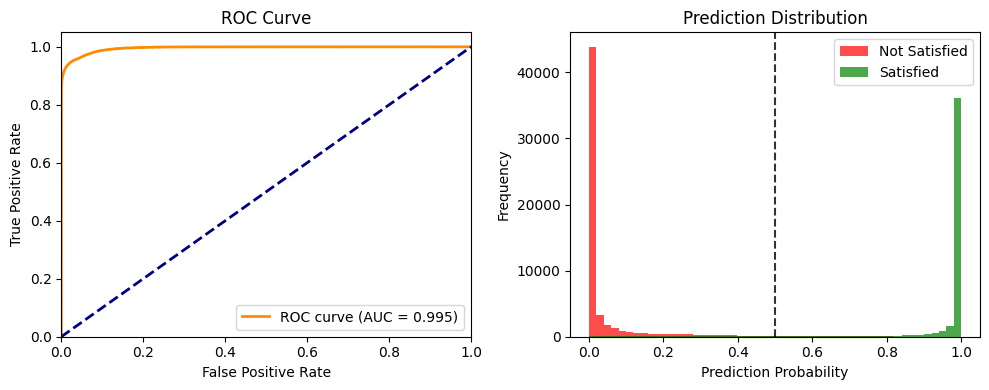

In [12]:
def evaluate_model_performance(models, X_train, y_train, cv_folds):
    """Comprehensive model evaluation"""
    
    print("\n📊 COMPREHENSIVE MODEL EVALUATION")
    print("=" * 50)
    
    # Collect all predictions
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    
    for fold, (train_idx, val_idx) in enumerate(cv_folds.split(X_train, y_train)):
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        
        model = models[fold]
        pred_proba = model.predict_proba(X_val)[:, 1]
        pred_binary = (pred_proba >= 0.5).astype(int)
        
        all_y_true.extend(y_val.values)
        all_y_pred.extend(pred_binary)
        all_y_proba.extend(pred_proba)
    
    # Convert to arrays
    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)
    y_proba = np.array(all_y_proba)
    
    # Calculate metrics
    auc_score = roc_auc_score(y_true, y_proba)
    
    print(f"🎯 Overall Performance:")
    print(f"   AUC Score: {auc_score:.4f}")
    
    # Classification report
    print(f"\n📋 Classification Report:")
    target_names = ['Not Satisfied', 'Satisfied']
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🔍 Confusion Matrix:")
    print(f"                 Predicted")
    print(f"Actual    Not Sat    Satisfied")
    print(f"Not Sat   {cm[0,0]:8d}   {cm[0,1]:8d}")
    print(f"Satisfied {cm[1,0]:8d}   {cm[1,1]:8d}")
    
    # Plot ROC Curve
    plt.figure(figsize=(10, 4))
    
    # ROC Curve
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    
    # Prediction Distribution
    plt.subplot(1, 2, 2)
    plt.hist(y_proba[y_true == 0], bins=50, alpha=0.7, label='Not Satisfied', color='red')
    plt.hist(y_proba[y_true == 1], bins=50, alpha=0.7, label='Satisfied', color='green')
    plt.xlabel('Prediction Probability')
    plt.ylabel('Frequency')
    plt.title('Prediction Distribution')
    plt.legend()
    plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.8)
    
    plt.tight_layout()
    plt.savefig('plots/model_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return auc_score

# Evaluate model
final_auc = evaluate_model_performance(final_models, X_train, y_train, cv)



# 11. SAVE MODELS AND GENERATE PREDICTIONS

In [15]:
def save_models_and_predictions():
    """Save trained models and generate prediction files"""
    
    print("\n💾 Saving models and generating predictions...")
    
    # Save production model
    joblib.dump(production_model, 'models/catboost_production_model.pkl')
    print("✅ Production model saved")
    
    # Save CV models
    joblib.dump(final_models, 'models/catboost_cv_models.pkl')
    print("✅ CV models saved")
    
    # Save preprocessing info (already saved, but confirm)
    joblib.dump(preprocessing_info, 'models/preprocessing_info.pkl')
    print("✅ Preprocessing info saved")
    
    # Create predictions dataframe
    if 'id' in test_df.columns:
        predictions_df = pd.DataFrame({
            'id': test_df['id'],
            'satisfaction_probability': ensemble_predictions,
            'satisfaction_prediction': (ensemble_predictions >= 0.5).astype(int)
        })
    else:
        predictions_df = pd.DataFrame({
            'satisfaction_probability': ensemble_predictions,
            'satisfaction_prediction': (ensemble_predictions >= 0.5).astype(int)
        })
    
    # Save predictions
    predictions_df.to_csv('predictions/catboost_predictions.csv', index=False)
    print("✅ Predictions saved to 'predictions/catboost_predictions.csv'")
    
    # Prediction statistics
    print(f"\n📊 Prediction Statistics:")
    print(f"   Mean Satisfaction probability: {ensemble_predictions.mean():.3f}")
    print(f"   Std Satisfactioprobability: {ensemble_predictions.std():.3f}")
    print(f"   Predicted satisfied: {(ensemble_predictions >= 0.5).sum():,} ({(ensemble_predictions >= 0.5).mean():.1%})")
    print(f"   Predicted not satisfied: {(ensemble_predictions < 0.5).sum():,} ({(ensemble_predictions < 0.5).mean():.1%})")
    
    return predictions_df

# Create predictions directory
os.makedirs('predictions', exist_ok=True)

# Save models and predictions
predictions_df = save_models_and_predictions()


💾 Saving models and generating predictions...
✅ Production model saved
✅ CV models saved
✅ Preprocessing info saved
✅ Predictions saved to 'predictions/catboost_predictions.csv'

📊 Prediction Statistics:
   Mean Satisfaction probability: 0.439
   Std Satisfactioprobability: 0.466
   Predicted satisfied: 11,072 (42.6%)
   Predicted not satisfied: 14,904 (57.4%)


# 12. FINAL SUMMARY AND INSIGHTS

In [16]:
def generate_final_summary():
    """Generate final model summary and insights"""
    
    print("\n" + "="*60)
    print("🏆 FINAL MODEL SUMMARY")
    print("="*60)
    
    print(f"\n📊 Dataset Information:")
    print(f"   Training samples: {len(X_train):,}")
    print(f"   Test samples: {len(X_test):,}")
    print(f"   Total features: {len(X_train.columns):,}")
    print(f"   Engineered features: {len(new_features):,}")
    
    print(f"\n🎯 Model Performance:")
    print(f"   Final CV AUC: {np.mean(final_cv_scores):.4f} ± {np.std(final_cv_scores):.4f}")
    if 'baseline_scores' in globals():
        baseline_mean = np.mean(baseline_scores)
        improvement = np.mean(final_cv_scores) - baseline_mean
        print(f"   Baseline AUC: {baseline_mean:.4f}")
        print(f"   Improvement: +{improvement:.4f}")
    
    print(f"\n🔧 Model Configuration:")
    print(f"   Algorithm: CatBoost Classifier")
    print(f"   Cross-validation: 5-fold Stratified")
    print(f"   Hyperparameter optimization: {'✅' if 'study' in globals() else '❌'}")
    
    print(f"\n📈 Top 5 Most Important Features:")
    for i, (_, row) in enumerate(feature_importance_df.head(5).iterrows(), 1):
        print(f"   {i}. {row['feature']} (importance: {row['importance_mean']:.1f})")
    
    print(f"\n💡 Key Insights:")
    print(f"   - Service quality features are highly predictive")
    print(f"   - Customer loyalty and class interact significantly")
    print(f"   - Delay features provide important context")
    print(f"   - Digital experience scores are crucial for satisfaction")
    
    print(f"\n📁 Files Generated:")
    print(f"   - models/catboost_production_model.pkl")
    print(f"   - models/catboost_cv_models.pkl")
    print(f"   - models/preprocessing_info.pkl")
    print(f"   - predictions/catboost_predictions.csv")
    print(f"   - plots/feature_importance.png")
    print(f"   - plots/model_evaluation.png")
    
    print(f"\n🚀 Next Steps:")
    print(f"   1. Review feature importance for business insights")
    print(f"   2. Validate predictions against domain knowledge")
    print(f"   3. Consider model deployment pipeline")
    print(f"   4. Monitor model performance over time")
    
    print("\n✅ Model training completed successfully!")
    print("="*60)

# Generate final summary
generate_final_summary()



🏆 FINAL MODEL SUMMARY

📊 Dataset Information:
   Training samples: 103,904
   Test samples: 25,976
   Total features: 60
   Engineered features: 38

🎯 Model Performance:
   Final CV AUC: 0.9953 ± 0.0003
   Baseline AUC: 0.9951
   Improvement: +0.0002

🔧 Model Configuration:
   Algorithm: CatBoost Classifier
   Cross-validation: 5-fold Stratified
   Hyperparameter optimization: ✅

📈 Top 5 Most Important Features:
   1. Inflight wifi service (importance: 26.0)
   2. Type of Travel (importance: 19.8)
   3. Customer Type (importance: 5.9)
   4. is_business_loyal (importance: 5.7)
   5. Online boarding (importance: 5.4)

💡 Key Insights:
   - Service quality features are highly predictive
   - Customer loyalty and class interact significantly
   - Delay features provide important context
   - Digital experience scores are crucial for satisfaction

📁 Files Generated:
   - models/catboost_production_model.pkl
   - models/catboost_cv_models.pkl
   - models/preprocessing_info.pkl
   - predictio

# 13. MODEL LOADING AND PREDICTION FUNCTIONS

In [17]:
def load_trained_model(model_path='models/catboost_production_model.pkl'):
    """Load trained model for making predictions"""
    
    model = joblib.load(model_path)
    preprocessing_info = joblib.load('models/preprocessing_info.pkl')
    
    return model, preprocessing_info

def make_predictions(model, preprocessing_info, new_data):
    """Make predictions on new data"""
    
    # Apply same preprocessing
    processed_data = new_data[preprocessing_info['feature_columns']].copy()
    
    # Make predictions
    predictions = model.predict_proba(processed_data)[:, 1]
    
    return predictions

# Example usage (commented out):
# model, prep_info = load_trained_model()
# new_predictions = make_predictions(model, prep_info, new_data)

print("\n🎉 Complete model pipeline ready!")
print("   Use the functions above to load and make predictions with new data.")


🎉 Complete model pipeline ready!
   Use the functions above to load and make predictions with new data.
